<a href="https://colab.research.google.com/github/ishanwa/Forecasting_project/blob/main/XGBRegressor/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import glob, os

In [5]:
data_folder = r"/content"
files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))


In [6]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100



Processing: RevenueCenter_3


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


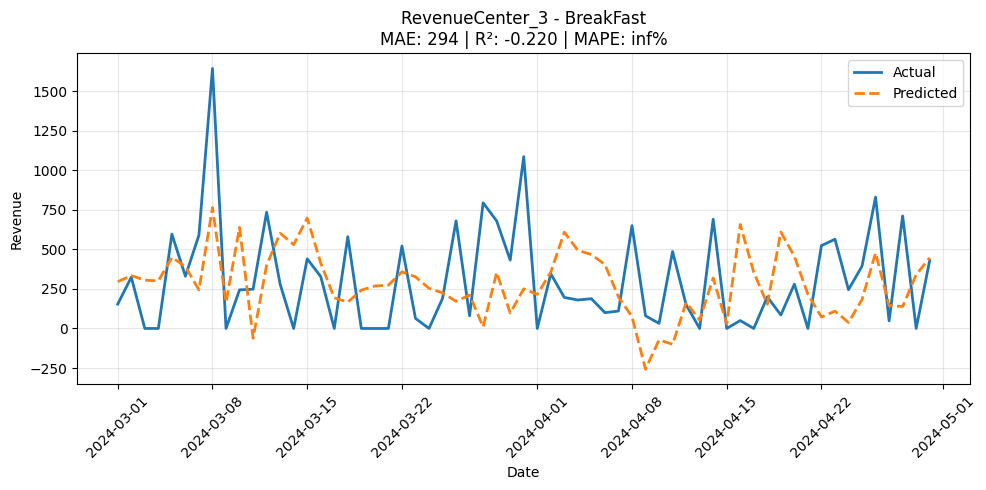

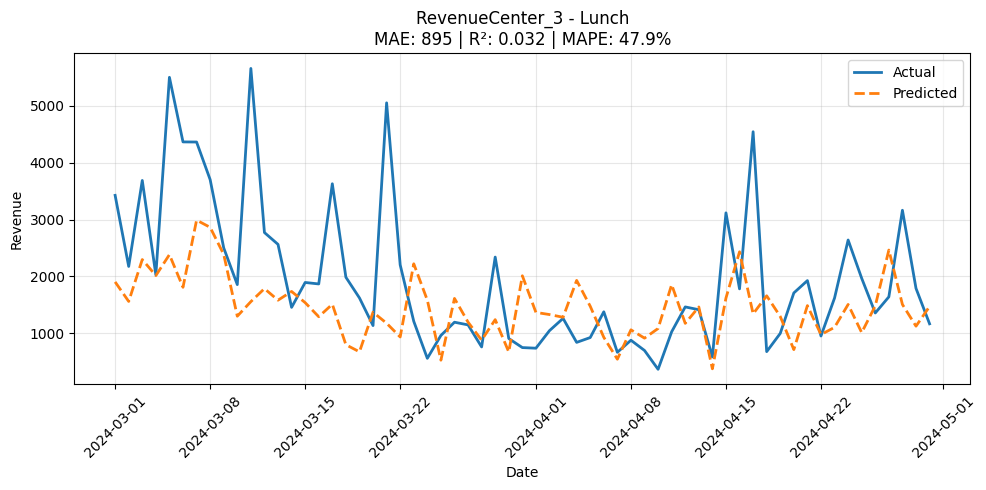

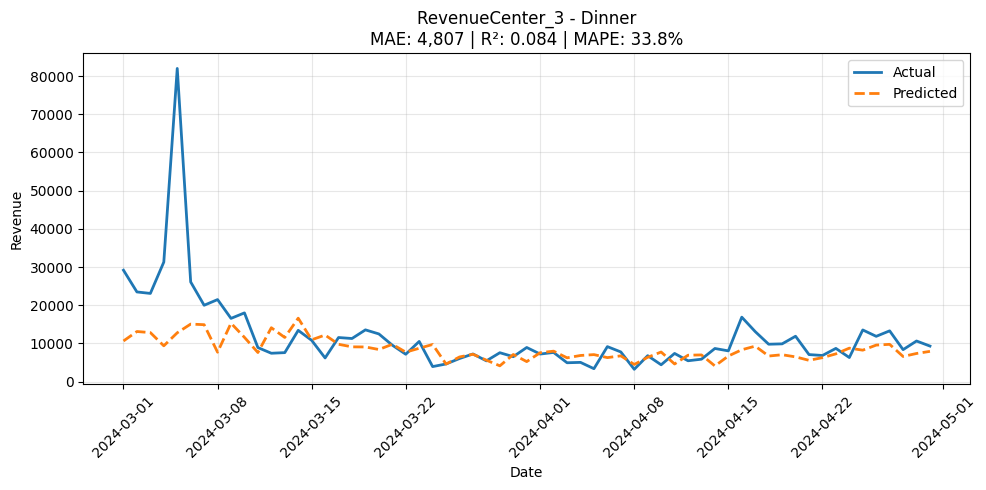


Processing: RevenueCenter_9


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


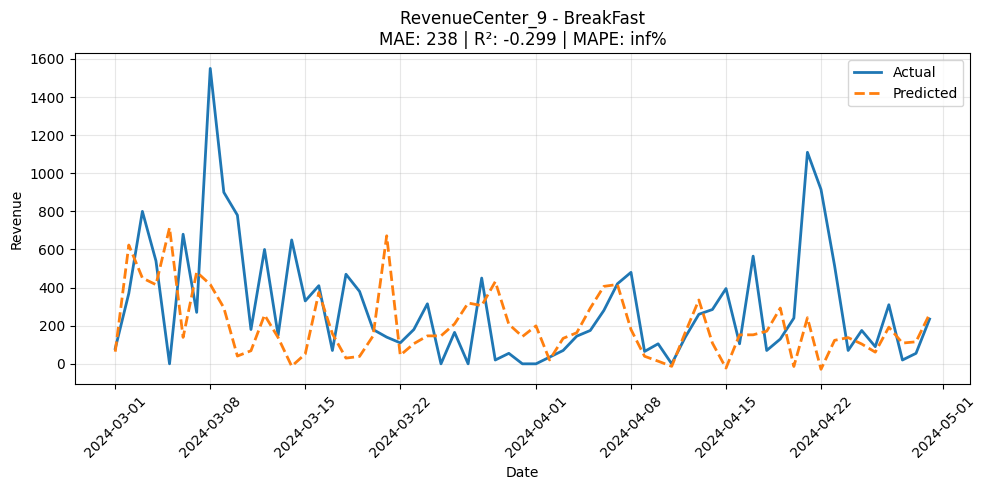

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


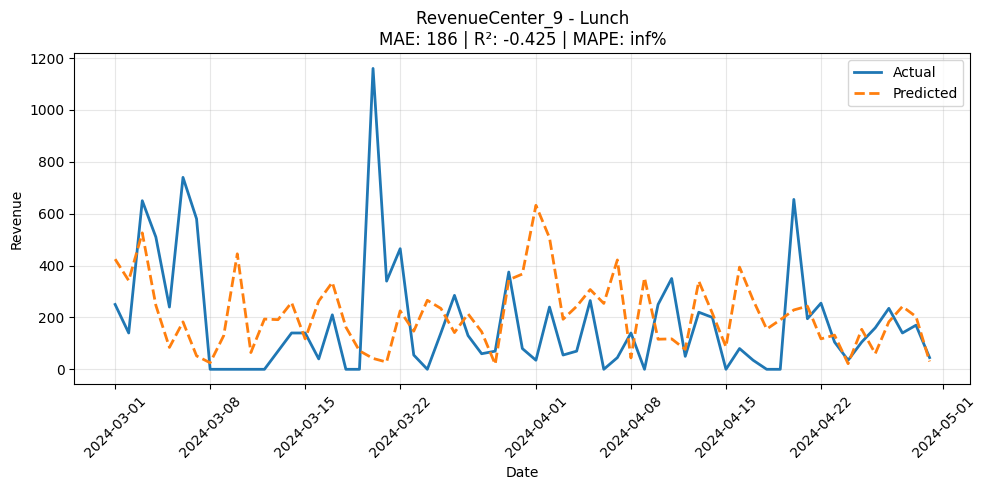

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


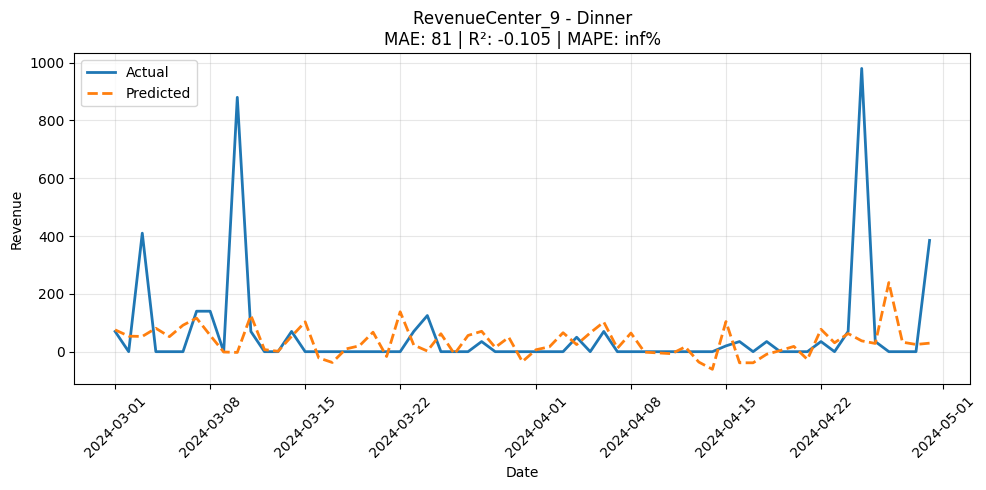


Processing: RevenueCenter_8


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


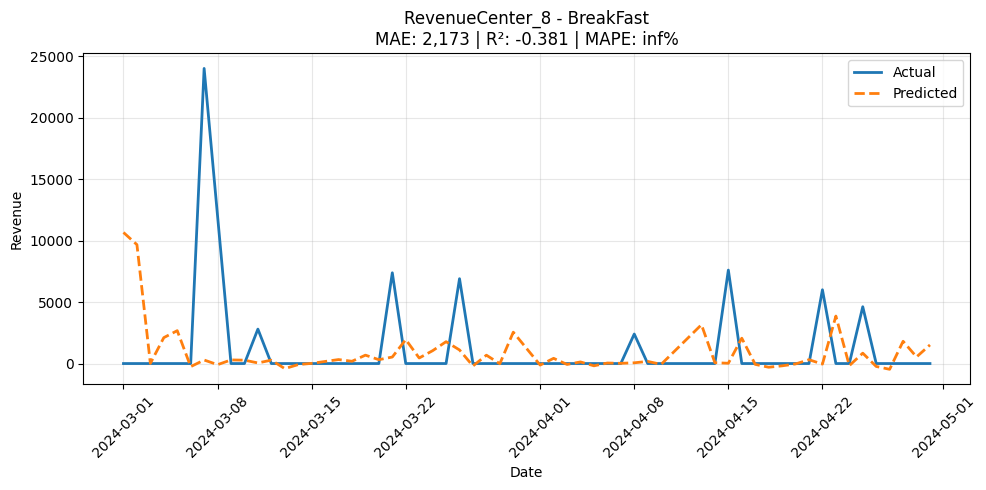

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


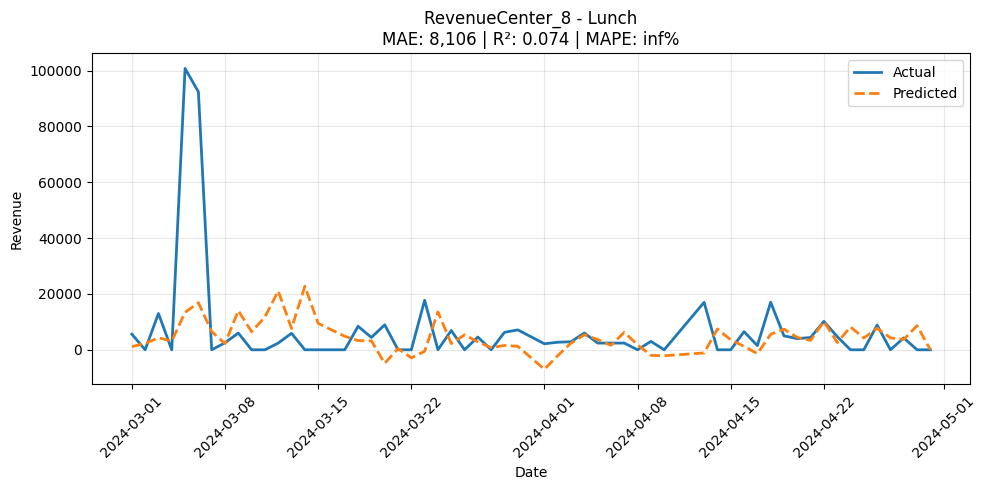

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


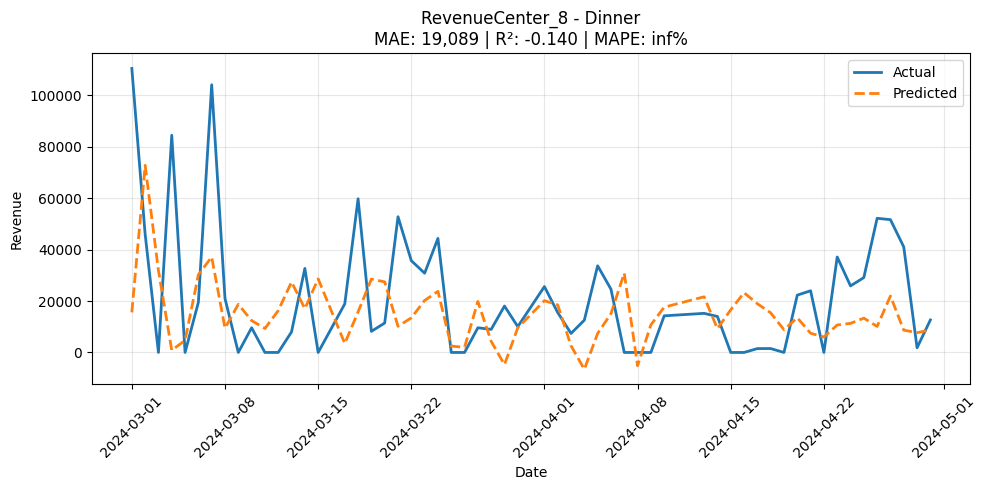


Processing: RevenueCenter_2


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


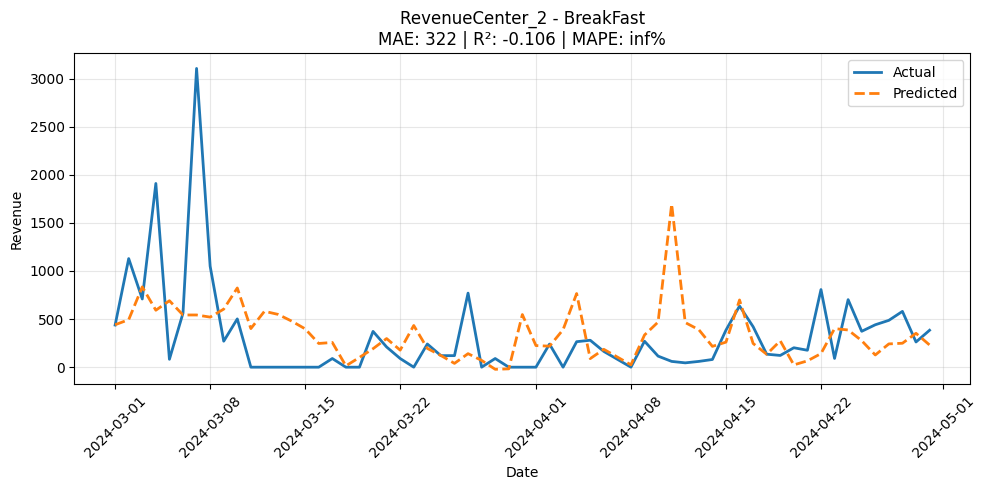

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


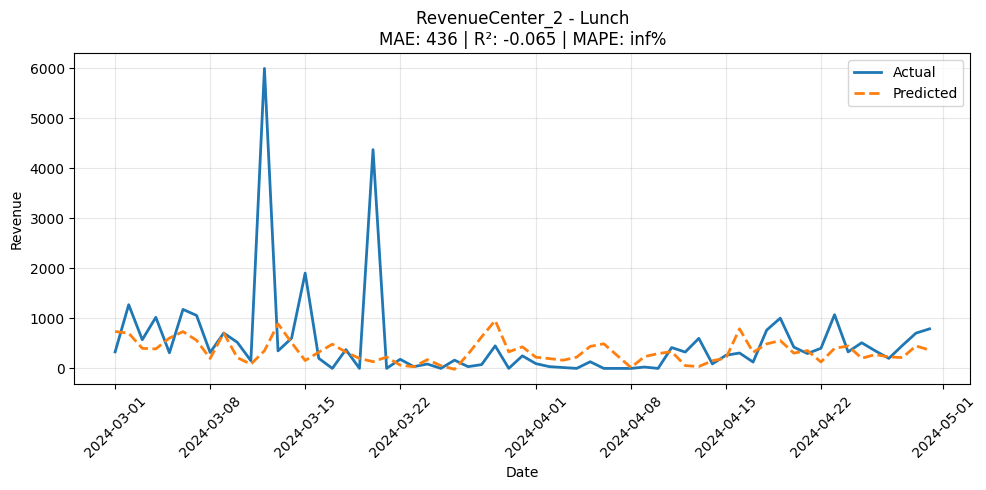

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


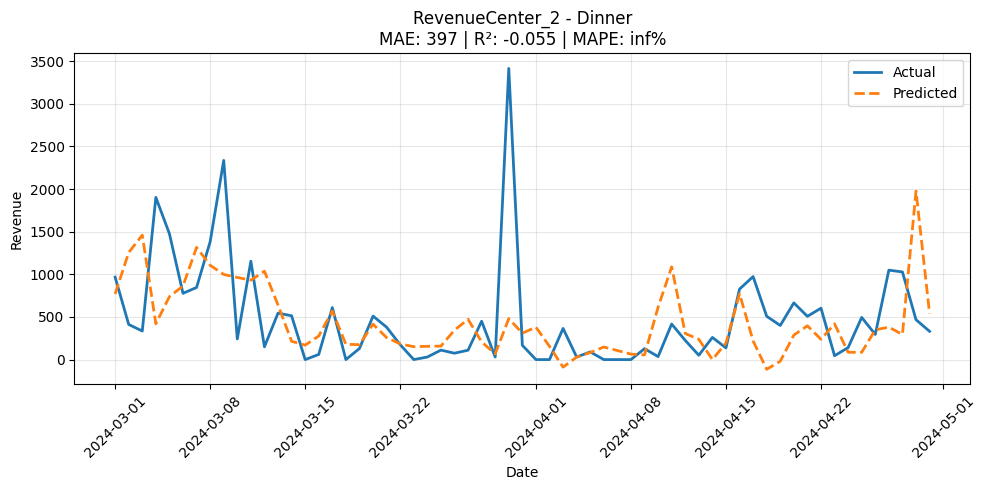


Processing: RevenueCenter_6


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


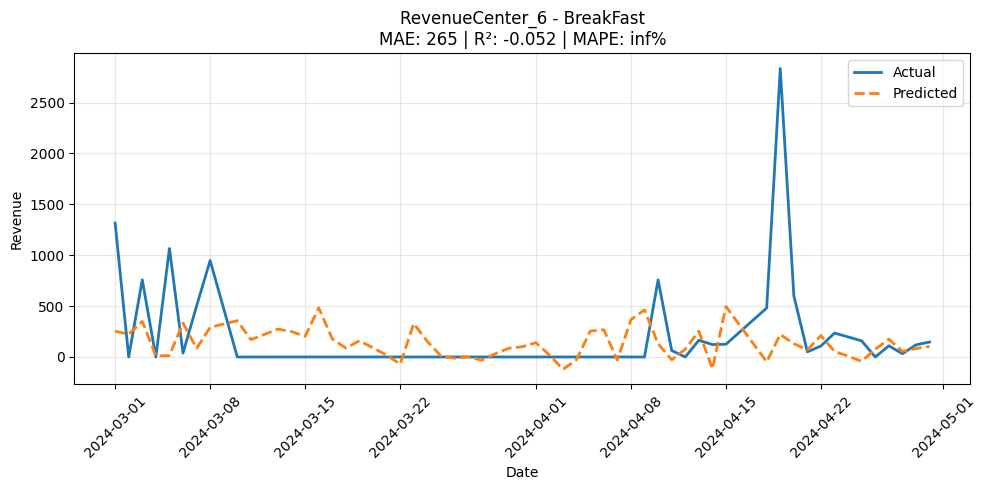

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


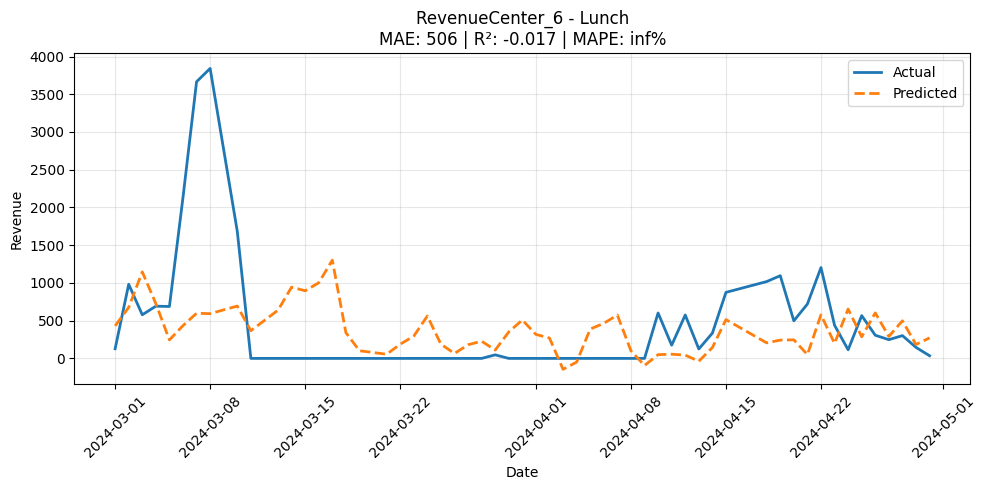

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


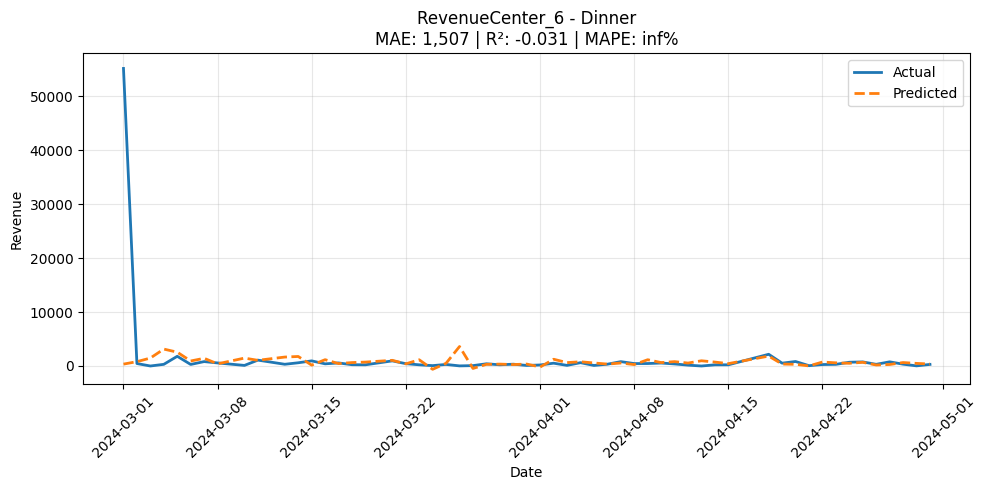


Processing: RevenueCenter_5


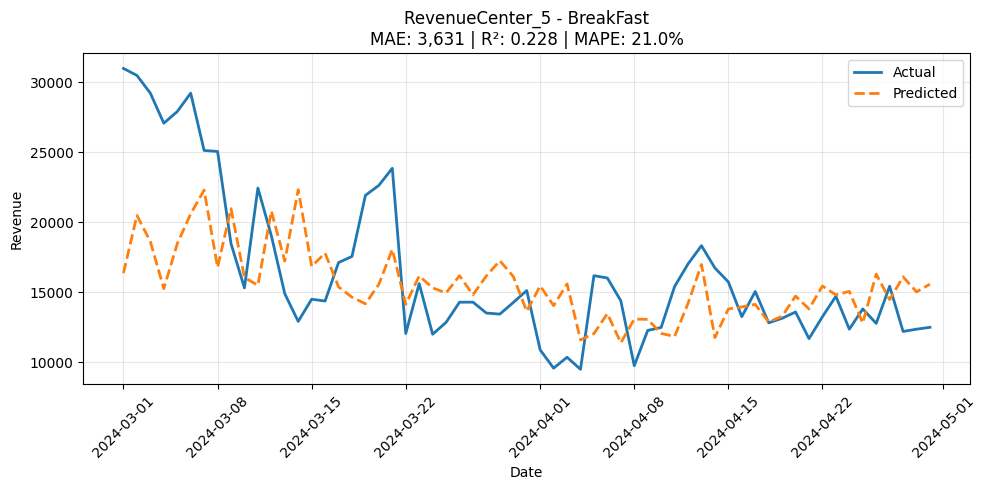

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


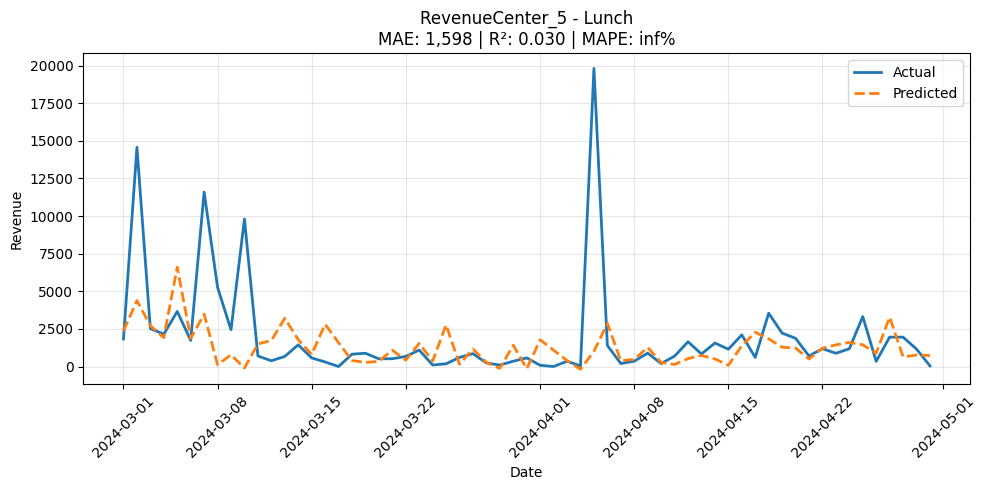

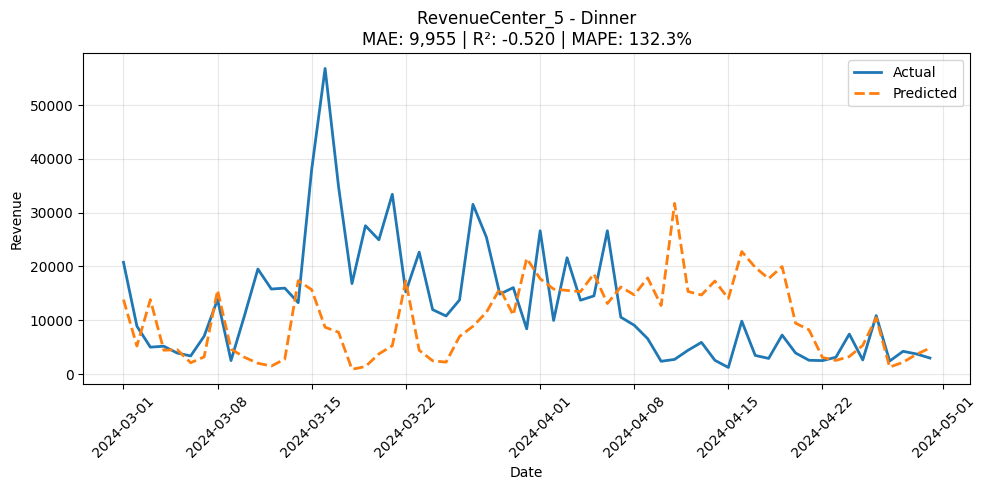


Processing: RevenueCenter_7


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


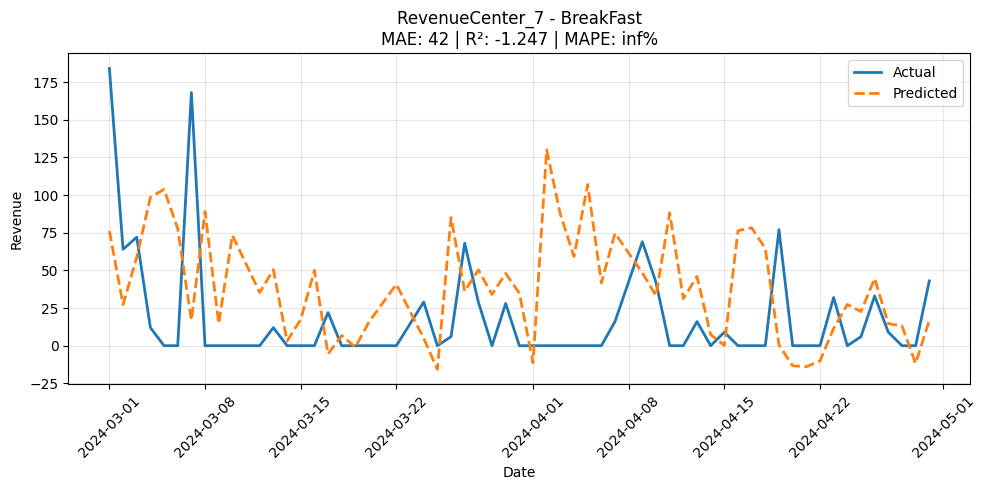

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


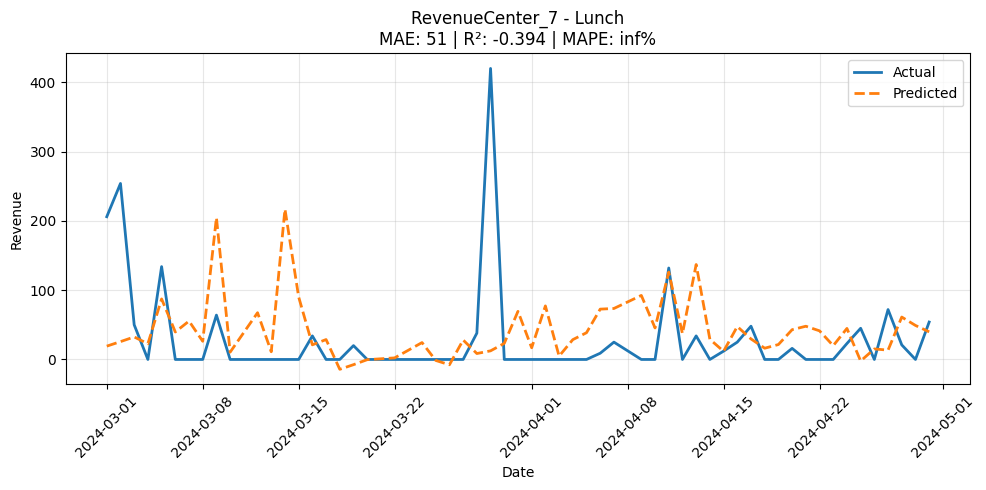

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


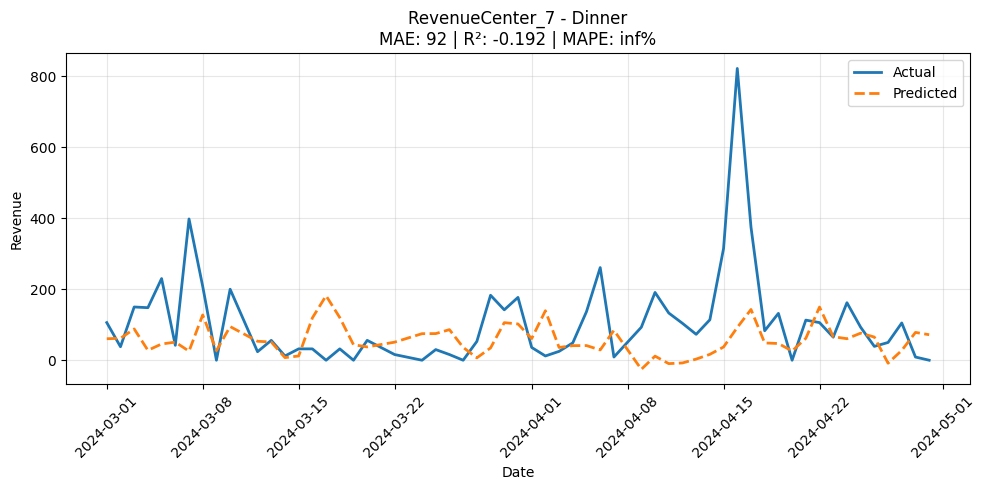


Processing: RevenueCenter_1


/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


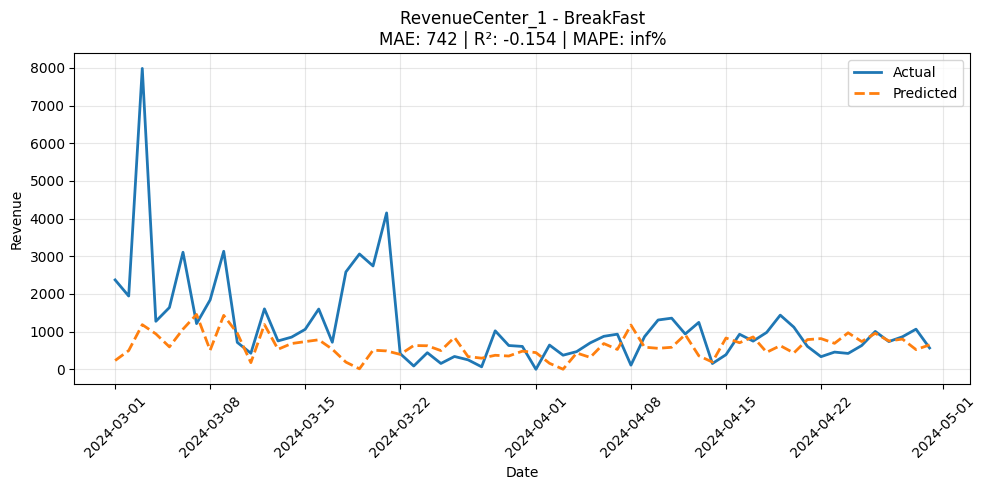

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


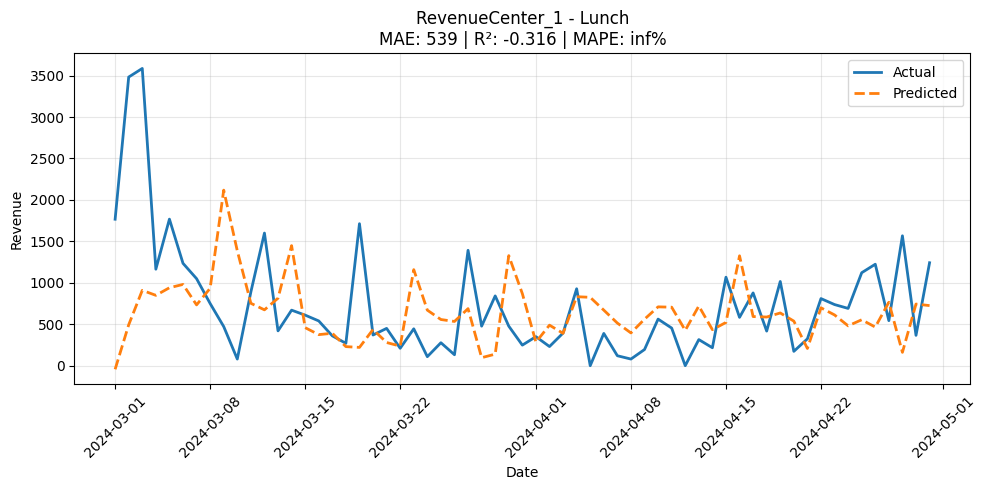

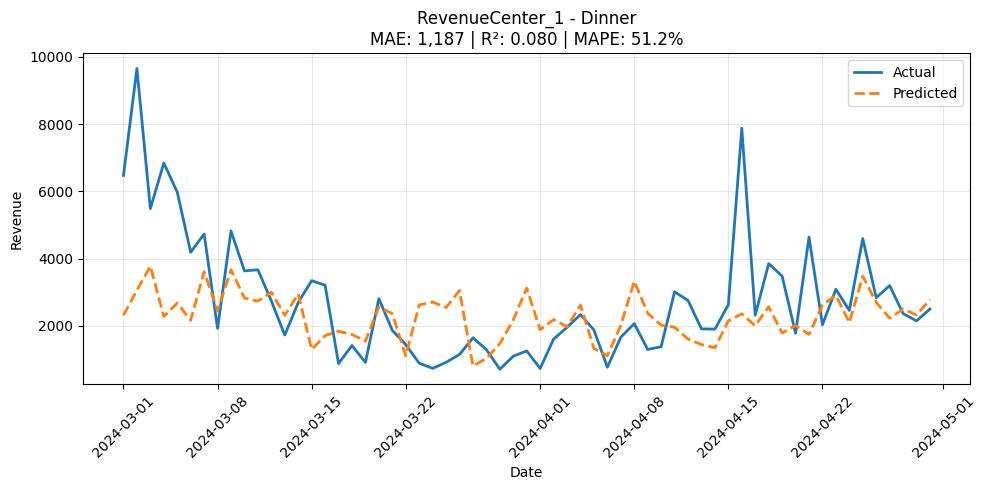


Processing: RevenueCenter_4


/tmp/ipython-input-443454161.py:3: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


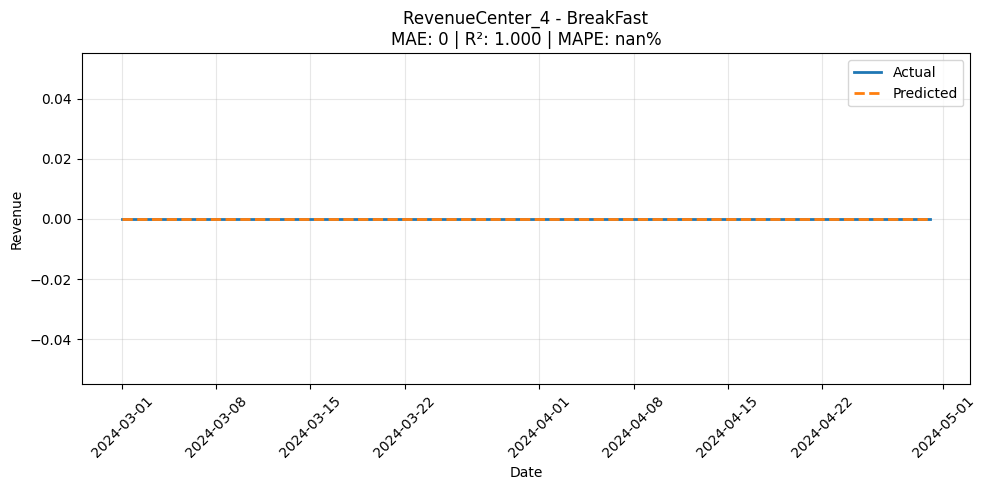

/tmp/ipython-input-443454161.py:3: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


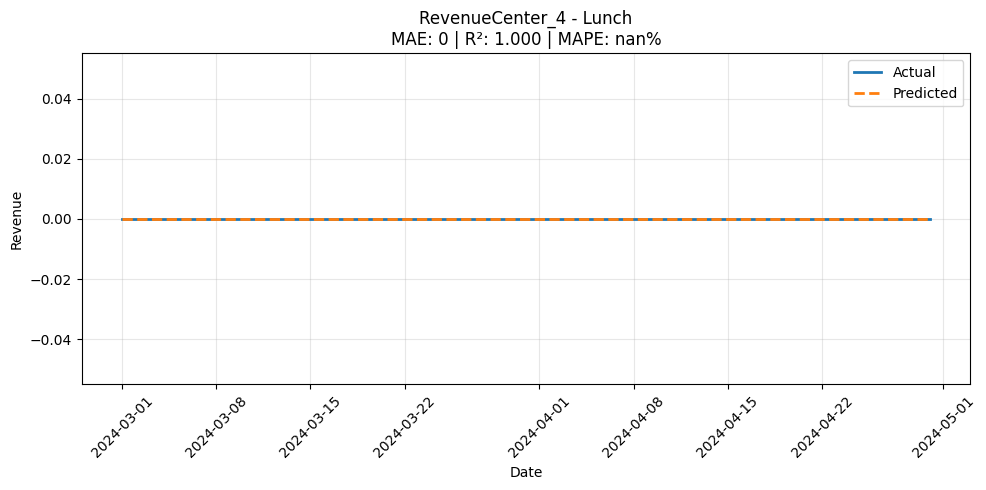

/tmp/ipython-input-443454161.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


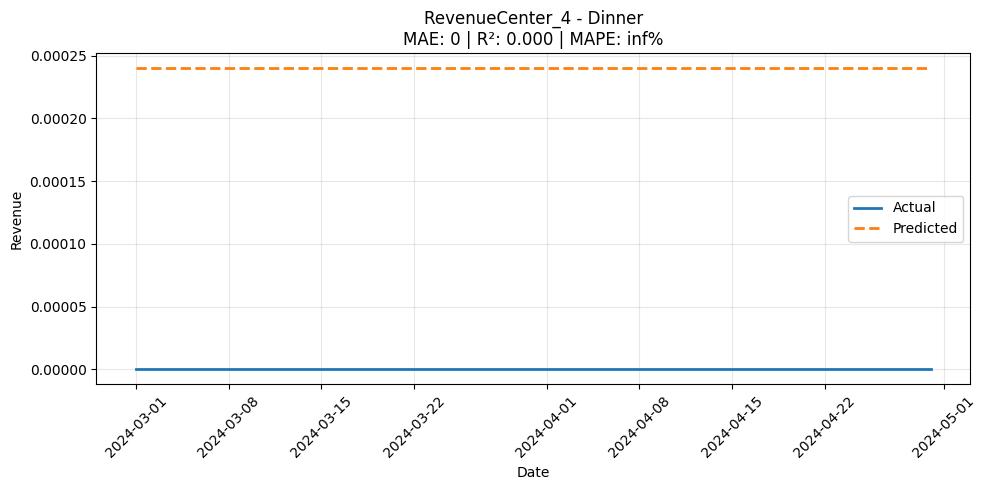

In [7]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["day_of_month"] = df["Date"].dt.day

    features = [
        "average_temperature",
        "weather_code",
        "IsWeekend",
        "IsHoliday",
        "day_of_week",
        "month",
        "day_of_month"
    ]

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    split_index = df[df["Date"] > split_date].index[0]

    X_train = df.loc[:split_index-1, features]
    X_test  = df.loc[split_index:, features]

    test_dates = df.loc[split_index:, "Date"]

    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        y_train = df.loc[:split_index-1, meal]
        y_test  = df.loc[split_index:, meal]

        model = xgb.XGBRegressor(
            n_estimators=1800,  # Number of trees (boosting rounds). More trees → better learning but higher risk of overfitting
            learning_rate=0.05,   # Step size shrinkage. smaller value → slower learning, better generalization,
            max_depth=5,       # Maximum depth of each decision tree. controls model complexity. larger depth → captures complex patterns but may overfit.
            reg_lambda=1.0,   # Ridge, Penalizes large weights and helps prevent overfitting.
            reg_alpha=0.1,   # L1 regularization (Lasso). encourages sparsity by shrinking less important features to zero.
            subsample=0.8,   # Fraction of training data used to grow each tree ,adds randomness and reduces overfitting.
            colsample_bytree=0.8,       # Fraction of features used for each tree. prevents reliance on a few dominant features.
            random_state=42,    # Ensures reproducible results across runs.
            verbosity=0    # Controls logging output, 0 = silent, higher values show more training details.
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae_value  = mean_absolute_error(y_test, y_pred)
        r2_value   = r2_score(y_test, y_pred)
        mape_value = mape(y_test, y_pred)

        plt.figure(figsize=(10, 5))

        plt.plot(test_dates, y_test, label="Actual", linewidth=2)
        plt.plot(test_dates, y_pred, "--", label="Predicted", linewidth=2)

        plt.title(
            f"{center_name} - {meal}\n"
            f"MAE: {mae_value:,.0f} | "
            f"R²: {r2_value:.3f} | "
            f"MAPE: {mape_value:.1f}%",
            fontsize=12
        )

        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



